## Cryptocurrency Volatility Regime Classification Using K-Nearest Neighbors (KNN)

The objective of this project is to classify Bitcoin trading days into Low and High volatility regimes using historical Bitcoin market data. KNN is used to classify the market regime based on the relationship between similar market observations.

## Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as py

from sklearn.linear_model import LinearRegression,Lasso,Ridge,ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error , mean_squared_error , root_mean_squared_error , r2_score
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.metrics import precision_score,accuracy_score,confusion_matrix,classification_report,recall_score,f1_score,roc_auc_score
from sklearn.neighbors import KNeighborsClassifier as KNN

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")

import joblib
import pickle

## Load and understand the original dataset

In [2]:
df = pd.read_csv("BTC-2017 per min.csv")
df.head()

,date,open,high,low,close,Volume BTC
0,31-12-2017 23:59,13913.28,13913.28,13867.18,13880.00,0.591748
1,31-12-2017 23:58,13913.26,13953.83,13884.69,13953.77,1.398784
2,31-12-2017 23:57,13908.73,13913.26,13874.99,13913.26,0.775012
3,31-12-2017 23:56,13827.00,13908.69,13827.00,13859.58,0.666459
4,31-12-2017 23:55,13825.05,13825.05,13825.05,13825.05,0.065501


In [3]:
df.shape

(525599, 6)

##### The original dataset contains 5,25,599 minute-level observations, so i will be converting it into daily observations ahead

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525599 entries, 0 to 525598
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   date        525599 non-null  object 
 1   open        525599 non-null  float64
 2   high        525599 non-null  float64
 3   low         525599 non-null  float64
 4   close       525599 non-null  float64
 5   Volume BTC  525599 non-null  float64
dtypes: float64(5), object(1)
memory usage: 24.1+ MB


In [5]:
#convert the dtype of "date" column to "datetime"

df['date'] = pd.to_datetime(df['date'])

In [6]:
df.dtypes

date          datetime64[ns]
open                 float64
high                 float64
low                  float64
close                float64
Volume BTC           float64
dtype: object

In [7]:
# Sort chronologically

df = df.sort_values("date")

In [8]:
df[['date']]

,date
525598,2017-01-01 00:01:00
525597,2017-01-01 00:02:00
525596,2017-01-01 00:03:00
525595,2017-01-01 00:04:00
525594,2017-01-01 00:05:00
...,...
4,2017-12-31 23:55:00
3,2017-12-31 23:56:00
2,2017-12-31 23:57:00
1,2017-12-31 23:58:00


## Convert minute-level data into daily data

In [9]:
##...... using "resample("D")" 

df = df.set_index("date")

daily = df.resample("D").agg({
    "open": "first",
    "high": "max",
    "low": "min",
    "close": "last",
    "Volume BTC": "sum"
}).reset_index()                    ##Just remember: after this, date is again a normal column because of .reset_index().

In [10]:
daily.shape

(365, 6)

In [11]:
##Create volatility

daily['volatility'] = (daily['high']-daily['low']) / daily['close']

daily.head()

,date,open,high,low,close,Volume BTC,volatility
0,2017-01-01,966.34,1005.00,960.53,997.75,6850.593309,0.044570
1,2017-01-02,997.75,1032.00,990.01,1012.54,8167.381030,0.041470
2,2017-01-03,1011.44,1039.00,999.99,1035.24,9089.658025,0.037682
3,2017-01-04,1035.51,1139.89,1028.56,1114.92,21562.456972,0.099855
4,2017-01-05,1114.38,1136.72,885.41,1004.74,36018.861120,0.250124


In [12]:
##We'll divide Bitcoin into Low Volatility and High Volatility.

median_volatility = daily["volatility"].median()

print(median_volatility)

0.060918801702674434


## Create the target variable

In [13]:
daily["volatility regime"] = (daily["volatility"] > median_volatility).astype(int)

daily.head()

,date,open,high,low,close,Volume BTC,volatility,volatility regime
0,2017-01-01,966.34,1005.00,960.53,997.75,6850.593309,0.044570,0
1,2017-01-02,997.75,1032.00,990.01,1012.54,8167.381030,0.041470,0
2,2017-01-03,1011.44,1039.00,999.99,1035.24,9089.658025,0.037682,0
3,2017-01-04,1035.51,1139.89,1028.56,1114.92,21562.456972,0.099855,1
4,2017-01-05,1114.38,1136.72,885.41,1004.74,36018.861120,0.250124,1


In [14]:
daily.shape

(365, 8)

In [15]:
# we dont need the "volatitlity" column as such in "x" while separating x and y 

In [16]:
daily["volatility regime"].value_counts()

volatility regime
0    183
1    182
Name: count, dtype: int64

In [17]:
## as we have used median so we got a balanced data

In [18]:
daily.isnull().sum()

date                 0
open                 0
high                 0
low                  0
close                0
Volume BTC           0
volatility           0
volatility regime    0
dtype: int64

In [19]:
daily.duplicated().sum()

np.int64(0)

## EDA:
Here we will analyze the original market variables and the volatitlity regime.

### 1. Bitcoin closing price over time:
You should see how Bitcoin's price changed throughout 2017 and whether there were major increases or fluctuations.

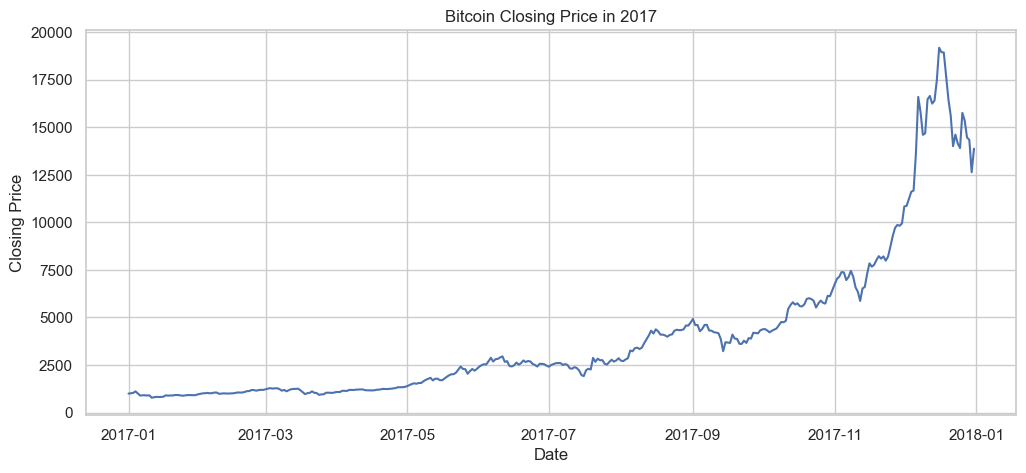

In [20]:

plt.figure(figsize=(12, 5))

plt.plot(daily["date"], daily["close"])

plt.title("Bitcoin Closing Price in 2017")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.show()

### 2. Bitcoin opening price over time

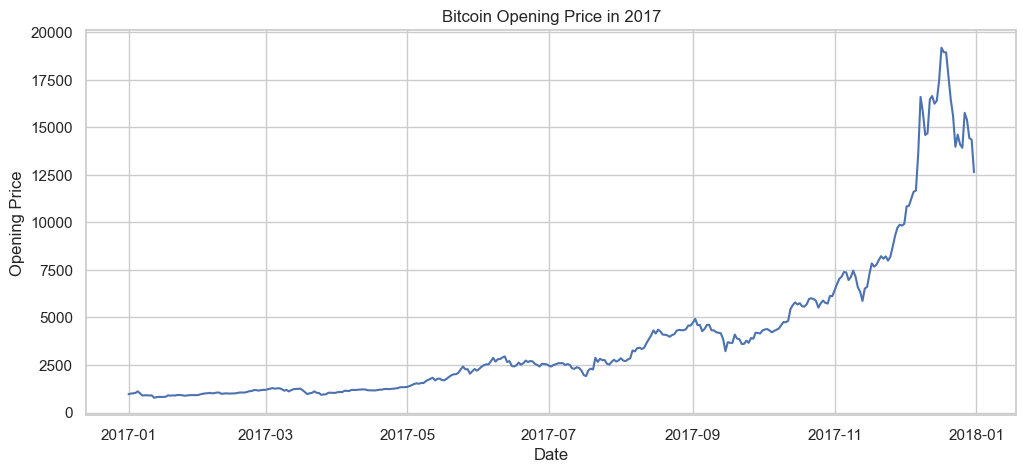

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(daily["date"], daily["open"])

plt.title("Bitcoin Opening Price in 2017")
plt.xlabel("Date")
plt.ylabel("Opening Price")

plt.show()

### 3. Distribution of volatility regimes

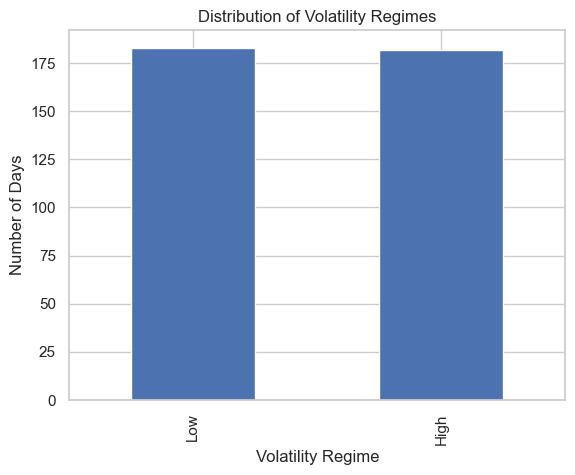

In [22]:
daily["volatility regime"].value_counts().plot(kind="bar")

plt.title("Distribution of Volatility Regimes")
plt.xlabel("Volatility Regime")
plt.ylabel("Number of Days")

plt.xticks([0, 1], ["Low", "High"])

plt.show()

### 4. Distribution of daily volatility: 
This helps you understand - whether most days have low or high volatility , whether there are extreme volatility values , the overall spread of volatility

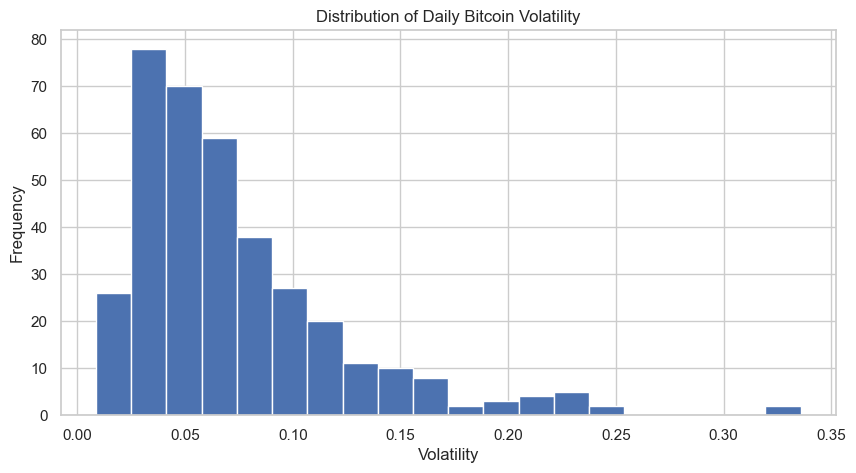

In [23]:
plt.figure(figsize=(10, 5))

plt.hist(daily["volatility"], bins=20)

plt.title("Distribution of Daily Bitcoin Volatility")
plt.xlabel("Volatility")
plt.ylabel("Frequency")

plt.show()

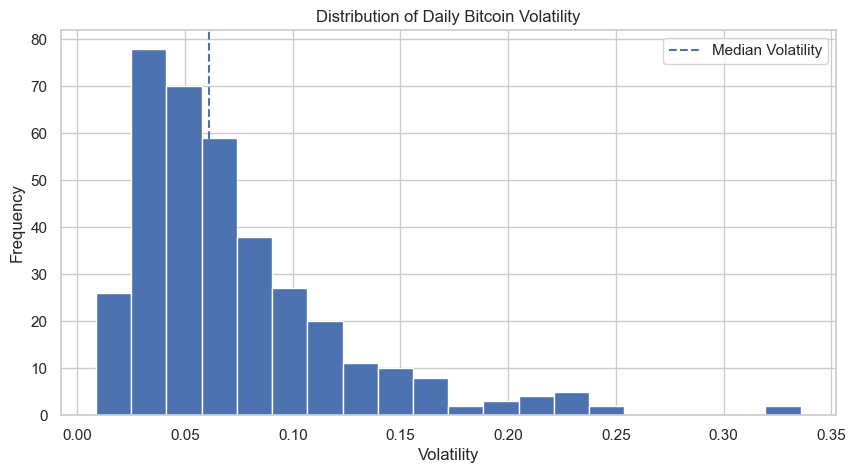

In [24]:
##This is particularly useful because the median line is what separates your Low and High volatility regimes.

plt.figure(figsize=(10, 5))

plt.hist(daily["volatility"], bins=20)

plt.axvline(
    median_volatility,
    linestyle="--",
    label="Median Volatility"
)

plt.title("Distribution of Daily Bitcoin Volatility")
plt.xlabel("Volatility")
plt.ylabel("Frequency")

plt.legend()
plt.show()

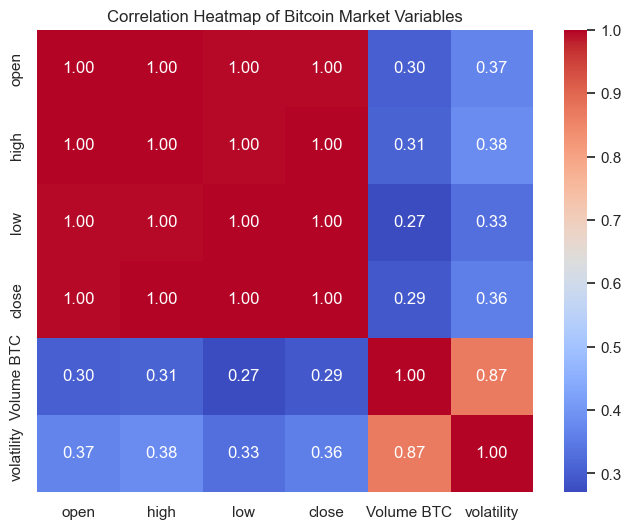

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.heatmap(
    daily[["open", "high", "low", "close", "Volume BTC", "volatility"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Bitcoin Market Variables")
plt.show()

### Simple interpretation:

The correlation analysis shows that Open, High, Low and Close prices are highly positively correlated, indicating that these market price variables move closely together. 
Volume BTC has the strongest positive correlation with daily volatility at 0.87, suggesting that higher trading activity is associated with greater market volatility. 
In comparison, individual price variables show a moderate positive relationship with volatility.

### NOTE: There's one simple fix- predict the NEXT day's volatility regime

The model should now learn:

Can today's Bitcoin market data help classify whether tomorrow will have Low or High volatility??

In [26]:
daily["target"] = daily["volatility regime"].shift(-1)

daily = daily.dropna()

daily["target"] = daily["target"].astype(int)

daily.tail()

,date,open,high,low,close,Volume BTC,volatility,volatility regime,target
359,2017-12-26,13925.50,16147.87,13746.95,15764.44,15051.164018,0.152300,1,1
360,2017-12-27,15764.45,16480.52,14484.00,15364.93,15643.754882,0.129940,1,1
361,2017-12-28,15390.05,15474.19,13500.00,14470.07,16557.217323,0.136433,1,1
362,2017-12-29,14436.99,15111.00,13998.00,14340.00,13505.702992,0.077615,1,1
363,2017-12-30,14351.00,14463.28,12050.00,12640.00,21749.674446,0.190924,1,1


In [27]:
daily.shape

(364, 9)

In [28]:
print(daily["date"].min())
print(daily["date"].max())

print(daily.index)

2017-01-01 00:00:00
2017-12-30 00:00:00
Index([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,
       ...
       354, 355, 356, 357, 358, 359, 360, 361, 362, 363],
      dtype='int64', length=364)


In [29]:
print(daily["date"].tail(10))

354   2017-12-21
355   2017-12-22
356   2017-12-23
357   2017-12-24
358   2017-12-25
359   2017-12-26
360   2017-12-27
361   2017-12-28
362   2017-12-29
363   2017-12-30
Name: date, dtype: datetime64[ns]


In [30]:
daily["daily_return"] = (daily["close"] - daily["open"]) / daily["open"]

In [31]:
#daily_return → how much the price moved from open to close
#volatility → how much the price fluctuated during the day
#Volume BTC → trading activity
#target → tomorrow's Low/High volatility regime

In [32]:
daily

,date,open,high,low,close,Volume BTC,volatility,volatility regime,target,daily_return
0,2017-01-01,966.34,1005.00,960.53,997.75,6850.593309,0.044570,0,0,0.032504
1,2017-01-02,997.75,1032.00,990.01,1012.54,8167.381030,0.041470,0,0,0.014823
2,2017-01-03,1011.44,1039.00,999.99,1035.24,9089.658025,0.037682,0,1,0.023531
3,2017-01-04,1035.51,1139.89,1028.56,1114.92,21562.456972,0.099855,1,1,0.076687
4,2017-01-05,1114.38,1136.72,885.41,1004.74,36018.861120,0.250124,1,1,-0.098387
...,...,...,...,...,...,...,...,...,...,...
359,2017-12-26,13925.50,16147.87,13746.95,15764.44,15051.164018,0.152300,1,1,0.132056
360,2017-12-27,15764.45,16480.52,14484.00,15364.93,15643.754882,0.129940,1,1,-0.025343
361,2017-12-28,15390.05,15474.19,13500.00,14470.07,16557.217323,0.136433,1,1,-0.059778
362,2017-12-29,14436.99,15111.00,13998.00,14340.00,13505.702992,0.077615,1,1,-0.006718


### Create Model : target is the actual column our KNN will predict.
**Separate x and y**

In [33]:
x = daily[["daily_return","volatility","Volume BTC"]]
y = daily["target"]

In [34]:
print("Features shape:", x.shape)
print("Target shape:", y.shape)

Features shape: (364, 3)
Target shape: (364,)


In [35]:
y.value_counts()

target
0    182
1    182
Name: count, dtype: int64

### Train-test split

In [36]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,shuffle=False)

#### Why shuffle=False?

Since Bitcoin data is time-based, I kept the earlier observations for training and the later observations for testing.

In [37]:
print("Training data:",x_train.shape)
print("Testing data:",x_test.shape)

Training data: (291, 3)
Testing data: (73, 3)


### Standardization

In [38]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)

x_test_scaled = scaler.transform(x_test)

### Training first KNN model :
First, let's start with K = 5:

In [39]:
knn = KNN(n_neighbors = 5)
knn.fit(x_train_scaled,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### Make predictions

In [40]:
y_pred = knn.predict(x_test_scaled)

### Now compare the predicted values with the actual target:

In [41]:
results = pd.DataFrame({"Actual":y_test , "Predicted":y_pred})

results.head()

,Actual,Predicted
291,1,1
292,0,1
293,1,1
294,1,1
295,1,1


### Evaluate your first KNN model

In [42]:
accuracy = accuracy_score(y_test,y_pred)

print("Accuracy Score:",accuracy)

Accuracy Score: 0.7123287671232876


In [43]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:",cm)

Confusion Matrix: [[12  9]
 [12 40]]


In [44]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training target distribution:
target
0    0.553265
1    0.446735
Name: proportion, dtype: float64

Testing target distribution:
target
1    0.712329
0    0.287671
Name: proportion, dtype: float64


In [45]:
for k in range(1, 11):
    knn = KNN(n_neighbors=k)
    knn.fit(x_train_scaled, y_train)
    y_pred = knn.predict(x_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"K = {k:<2} | Accuracy = {accuracy:.4f} | Precision = {precision:.4f} | Recall = {recall:.4f} | F1 Score = {f1:.4f}")

K = 1  | Accuracy = 0.5616 | Precision = 0.7632 | Recall = 0.5577 | F1 Score = 0.6444
K = 2  | Accuracy = 0.3836 | Precision = 0.6667 | Recall = 0.2692 | F1 Score = 0.3836
K = 3  | Accuracy = 0.6849 | Precision = 0.7959 | Recall = 0.7500 | F1 Score = 0.7723
K = 4  | Accuracy = 0.5890 | Precision = 0.8056 | Recall = 0.5577 | F1 Score = 0.6591
K = 5  | Accuracy = 0.7123 | Precision = 0.8163 | Recall = 0.7692 | F1 Score = 0.7921
K = 6  | Accuracy = 0.6575 | Precision = 0.8140 | Recall = 0.6731 | F1 Score = 0.7368
K = 7  | Accuracy = 0.7123 | Precision = 0.8039 | Recall = 0.7885 | F1 Score = 0.7961
K = 8  | Accuracy = 0.6575 | Precision = 0.7872 | Recall = 0.7115 | F1 Score = 0.7475
K = 9  | Accuracy = 0.6986 | Precision = 0.8000 | Recall = 0.7692 | F1 Score = 0.7843
K = 10 | Accuracy = 0.6712 | Precision = 0.8043 | Recall = 0.7115 | F1 Score = 0.7551


In [46]:
#Before plotting thee line chart we need to declare x and y 

k_values = []
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

for k in range(1, 11):
    knn = KNN(n_neighbors=k)
    knn.fit(x_train_scaled, y_train)
    y_pred = knn.predict(x_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    k_values.append(k)
    accuracy_scores.append(accuracy)
    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)

    print(f"K = {k:<2} | Accuracy = {accuracy:.4f} | Precision = {precision:.4f} | Recall = {recall:.4f} | F1 Score = {f1:.4f}")

K = 1  | Accuracy = 0.5616 | Precision = 0.7632 | Recall = 0.5577 | F1 Score = 0.6444
K = 2  | Accuracy = 0.3836 | Precision = 0.6667 | Recall = 0.2692 | F1 Score = 0.3836
K = 3  | Accuracy = 0.6849 | Precision = 0.7959 | Recall = 0.7500 | F1 Score = 0.7723
K = 4  | Accuracy = 0.5890 | Precision = 0.8056 | Recall = 0.5577 | F1 Score = 0.6591
K = 5  | Accuracy = 0.7123 | Precision = 0.8163 | Recall = 0.7692 | F1 Score = 0.7921
K = 6  | Accuracy = 0.6575 | Precision = 0.8140 | Recall = 0.6731 | F1 Score = 0.7368
K = 7  | Accuracy = 0.7123 | Precision = 0.8039 | Recall = 0.7885 | F1 Score = 0.7961
K = 8  | Accuracy = 0.6575 | Precision = 0.7872 | Recall = 0.7115 | F1 Score = 0.7475
K = 9  | Accuracy = 0.6986 | Precision = 0.8000 | Recall = 0.7692 | F1 Score = 0.7843
K = 10 | Accuracy = 0.6712 | Precision = 0.8043 | Recall = 0.7115 | F1 Score = 0.7551


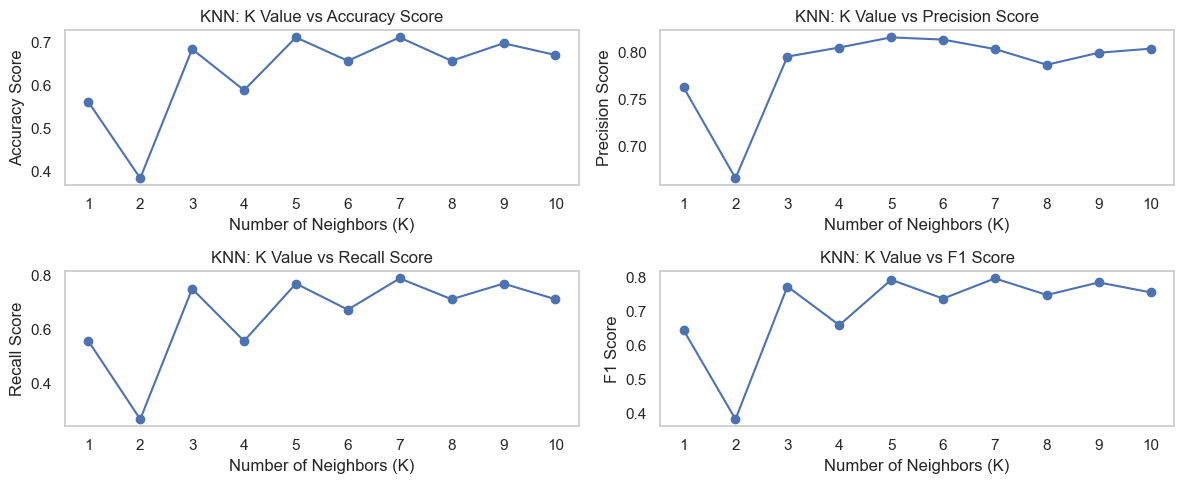

In [47]:
#Now in order to plot linechart of the above code 

plt.figure(figsize=(12, 5))

# Accuracy graph
plt.subplot(2, 2, 1)            #2(rows) * 2(columns) * 1(position)
plt.plot(k_values, accuracy_scores, marker='o')
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy Score")
plt.title("KNN: K Value vs Accuracy Score")
plt.xticks(k_values)
plt.grid()

# Precision graph
plt.subplot(2, 2, 2)
plt.plot(k_values, precision_scores, marker='o')
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Precision Score")
plt.title("KNN: K Value vs Precision Score")
plt.xticks(k_values)
plt.grid()


# Recall graph
plt.subplot(2, 2, 3)
plt.plot(k_values, recall_scores, marker='o')
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Recall Score")
plt.title("KNN: K Value vs Recall Score")
plt.xticks(k_values)
plt.grid()


# F1 graph
plt.subplot(2, 2, 4)
plt.plot(k_values, f1_scores, marker='o')
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("F1 Score")
plt.title("KNN: K Value vs F1 Score")
plt.xticks(k_values)
plt.grid()


plt.tight_layout()
plt.show()

K = 1 Confusion Matrix = [[12  9]
 [23 29]]


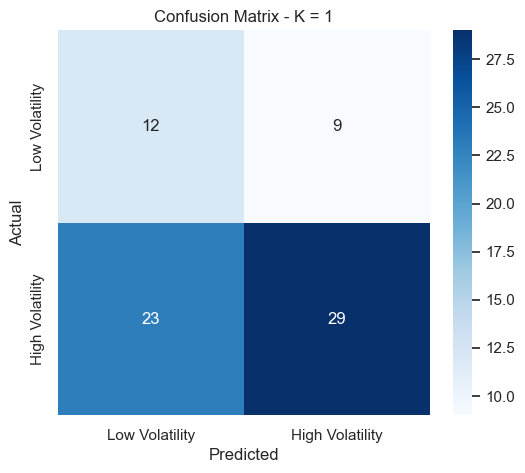

K = 2 Confusion Matrix = [[14  7]
 [38 14]]


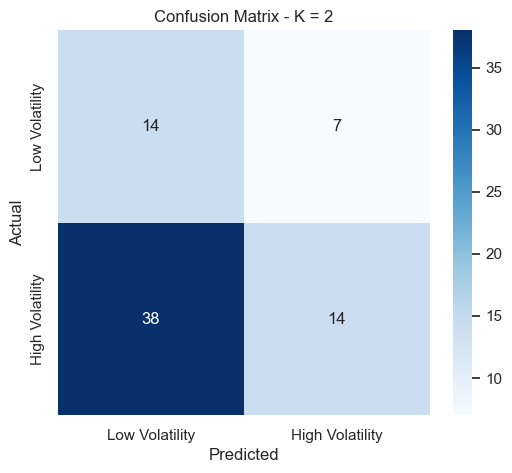

K = 3 Confusion Matrix = [[11 10]
 [13 39]]


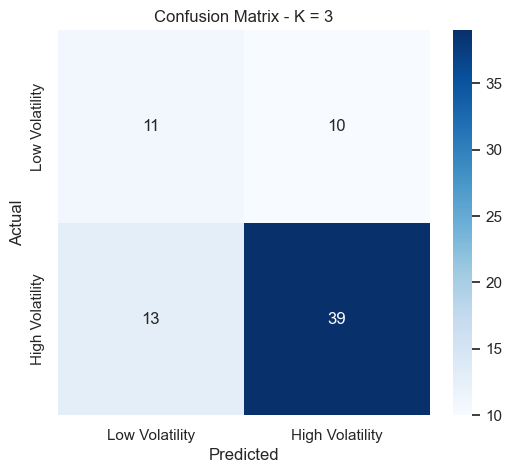

K = 4 Confusion Matrix = [[14  7]
 [23 29]]


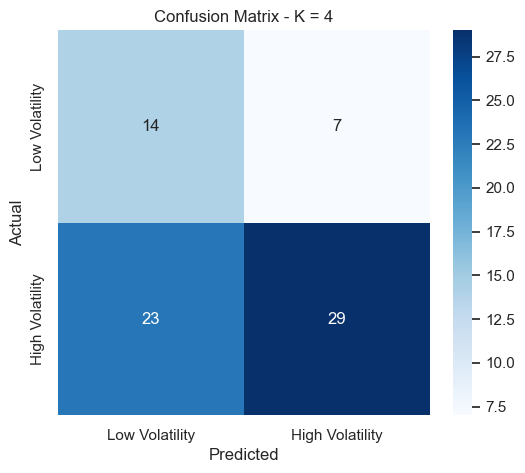

K = 5 Confusion Matrix = [[12  9]
 [12 40]]


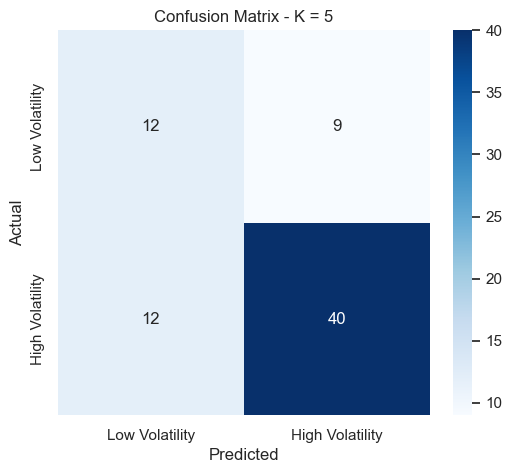

K = 6 Confusion Matrix = [[13  8]
 [17 35]]


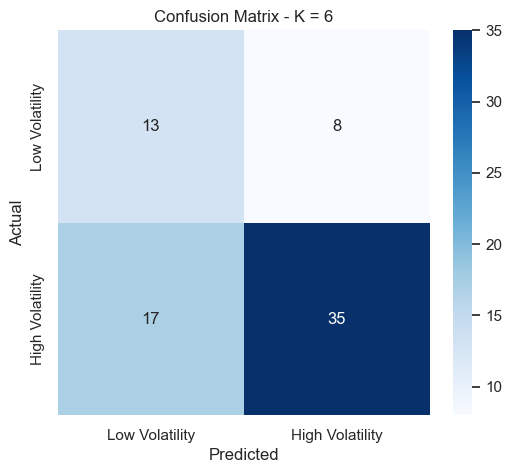

K = 7 Confusion Matrix = [[11 10]
 [11 41]]


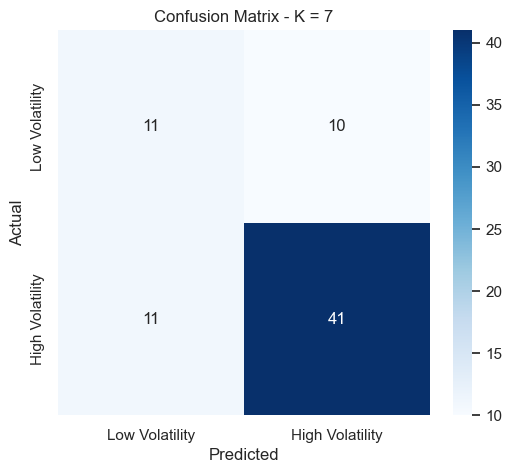

K = 8 Confusion Matrix = [[11 10]
 [15 37]]


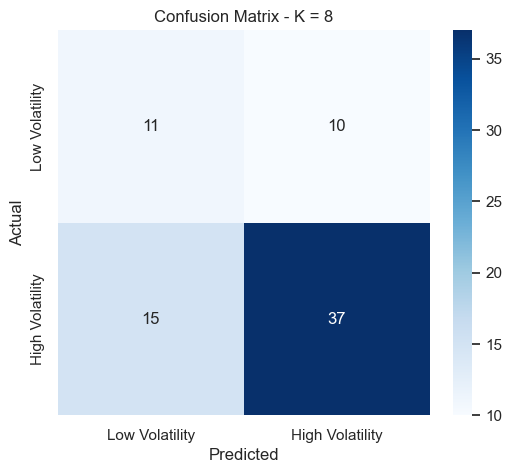

K = 9 Confusion Matrix = [[11 10]
 [12 40]]


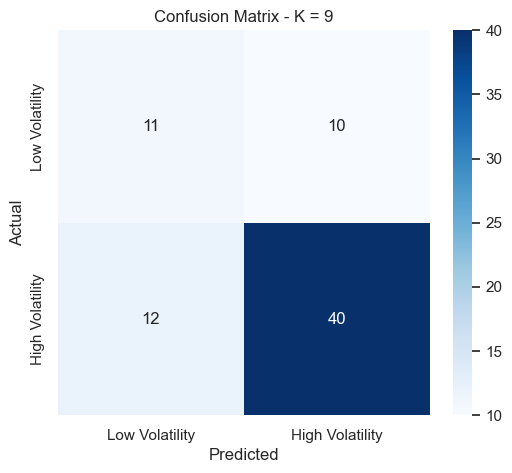

K = 10 Confusion Matrix = [[12  9]
 [15 37]]


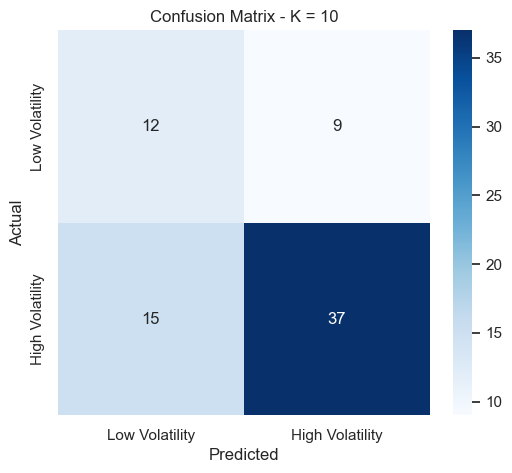

In [48]:
for k in range(1, 11):
    knn = KNN(n_neighbors=k)
    knn.fit(x_train_scaled, y_train)
    y_pred = knn.predict(x_test_scaled)

    cm = confusion_matrix(y_test, y_pred)

    print("K =", k, "Confusion Matrix =", cm)

    plt.figure(figsize=(6, 5))

    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",
        xticklabels=["Low Volatility", "High Volatility"],
        yticklabels=["Low Volatility", "High Volatility"])

    plt.title("Confusion Matrix - K = " + str(k))
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [49]:
for k in range(1, 11):
    knn = KNN(n_neighbors=k)
    knn.fit(x_train_scaled, y_train)
    y_pred = knn.predict(x_test_scaled)
    print("K =", k, "Classification report =",classification_report(y_test, y_pred) ,end ="\n\n")

K = 1 Classification report =               precision    recall  f1-score   support

           0       0.34      0.57      0.43        21
           1       0.76      0.56      0.64        52

    accuracy                           0.56        73
   macro avg       0.55      0.56      0.54        73
weighted avg       0.64      0.56      0.58        73


K = 2 Classification report =               precision    recall  f1-score   support

           0       0.27      0.67      0.38        21
           1       0.67      0.27      0.38        52

    accuracy                           0.38        73
   macro avg       0.47      0.47      0.38        73
weighted avg       0.55      0.38      0.38        73


K = 3 Classification report =               precision    recall  f1-score   support

           0       0.46      0.52      0.49        21
           1       0.80      0.75      0.77        52

    accuracy                           0.68        73
   macro avg       0.63      0.64   

In [50]:
for k in range(1, 11):
    knn = KNN(n_neighbors=k)
    knn.fit(x_train_scaled, y_train)
    y_pred = knn.predict(x_test_scaled)

    roc_auc = roc_auc_score(y_test, y_pred)
    
    print("K =", k, "ROC_AUC=",roc_auc)

K = 1 ROC_AUC= 0.5645604395604396
K = 2 ROC_AUC= 0.467948717948718
K = 3 ROC_AUC= 0.6369047619047619
K = 4 ROC_AUC= 0.6121794871794872
K = 5 ROC_AUC= 0.6703296703296703
K = 6 ROC_AUC= 0.6460622710622711
K = 7 ROC_AUC= 0.6561355311355311
K = 8 ROC_AUC= 0.6176739926739927
K = 9 ROC_AUC= 0.6465201465201466
K = 10 ROC_AUC= 0.6414835164835165


In [51]:
#w/o specifiying the k value works but....

print("Training score:", knn.score(x_train_scaled, y_train))
print("Testing score:", knn.score(x_test_scaled, y_test))

Training score: 0.7594501718213058
Testing score: 0.6712328767123288


In [52]:
 #since accuracy,recall and f1 score are highest at 5 and 7, so its better that we do

knn = KNN(n_neighbors=5)              

knn.fit(x_train_scaled, y_train)

print("K = 5")
print("Training score:", round(knn.score(x_train_scaled, y_train),4))
print("Testing score:", round(knn.score(x_test_scaled, y_test),4))

print()    #empty line

knn = KNN(n_neighbors=7)              

knn.fit(x_train_scaled, y_train)

print("K = 7")
print("Training score:", round(knn.score(x_train_scaled, y_train),4))
print("Testing score:", round(knn.score(x_test_scaled, y_test),4))

K = 5
Training score: 0.7835
Testing score: 0.7123

K = 7
Training score: 0.7904
Testing score: 0.7123


### Now find the optimal K / improve the KNN model / select the best K, then this Elbow step comes into picture
The purpose is to find a good value of K rather than arbitrarily saying K = 5 or K = 7

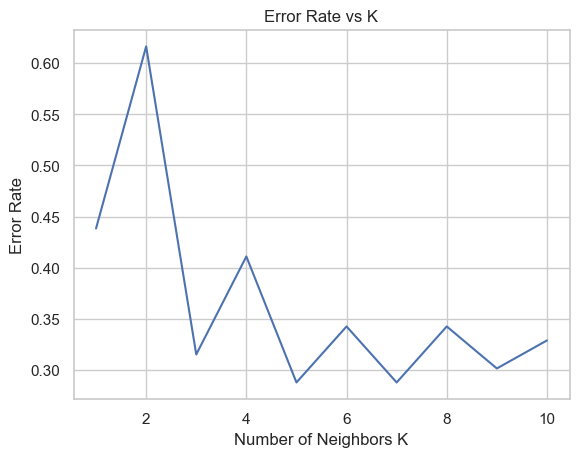

In [53]:
error_rate = []

for k in range(1, 11):
    knn = KNN(n_neighbors=k)
    knn.fit(x_train_scaled, y_train)
    
    y_pred = knn.predict(x_test_scaled)
    
    error = 1 - accuracy_score(y_test, y_pred)
    error_rate.append(error)

plt.plot(range(1, 11), error_rate)
plt.xlabel("Number of Neighbors K")
plt.ylabel("Error Rate")
plt.title("Error Rate vs K")
plt.show()

#### Insight: 
From the error-rate graph, K = 5 and K = 7 gives the minimum error rate. Since both perform similarly, K = 5 or k = 7 any can be selected as the final value of K.